# 16. Güneş Lekesi Aktivitesi Tahmini

**Kategori:** Zaman Serisi  
**Gerçek veri seti:** Annual Sunspots (statsmodels)  
**Veri kaynağı:** [https://www.statsmodels.org/stable/datasets/generated/sunspots.html](https://www.statsmodels.org/stable/datasets/generated/sunspots.html)  
**Amaç:** Yıllık güneş lekesi sayısını tarihsel gecikmeler ve yaklaşık 11 yıllık döngüyle tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Zaman serisi EDA'sı

In [2]:
df = pd.read_csv(DATA_DIR / "sunspots_annual.csv")
df.year = df.year.astype(int)
display(df.head())
print("Yıl aralığı:", df.year.min(), "-", df.year.max(), "| Eksik:", int(df.isna().sum().sum()))
display(df.sunspots.describe().to_frame().T)

Yıl aralığı: 1700 - 2008 | Eksik: 0


,year,sunspots
0,1700,5.0
1,1701,11.0
2,1702,16.0
3,1703,23.0
4,1704,36.0


,count,mean,std,min,25%,50%,75%,max
sunspots,309.0,49.752104,40.452595,0.0,16.0,40.0,69.8,190.2


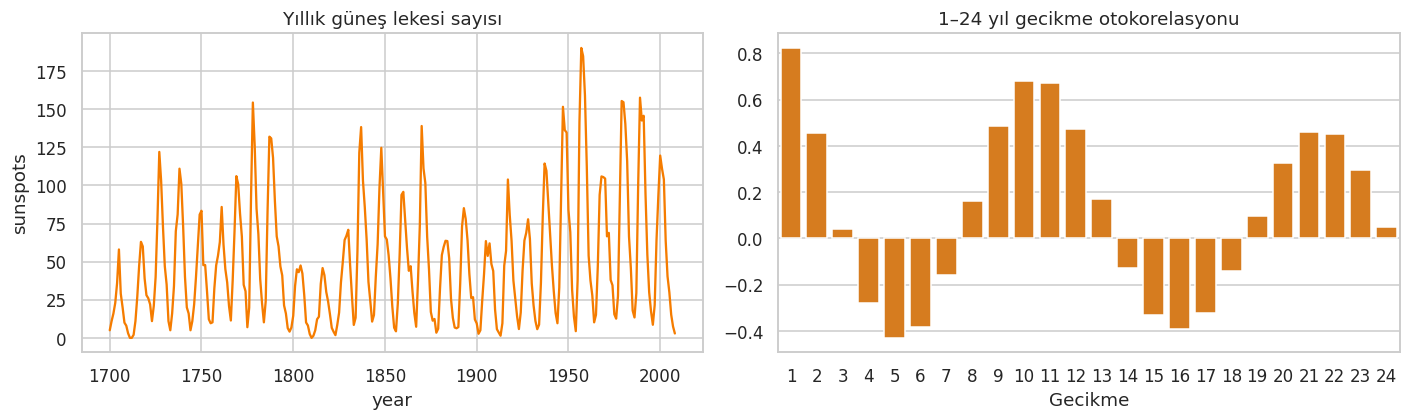

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=df, x="year", y="sunspots", ax=axes[0], color="#F57C00")
axes[0].set(title="Yıllık güneş lekesi sayısı")
acf_values = [df.sunspots.autocorr(lag) for lag in range(1, 25)]
sns.barplot(x=np.arange(1, 25), y=acf_values, ax=axes[1], color="#F57C00")
axes[1].set(title="1–24 yıl gecikme otokorelasyonu", xlabel="Gecikme")
plt.tight_layout(); plt.show()

## 2. İleri dönem tahmini

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

series = df.set_index("year").sunspots
features = pd.DataFrame({
    "lag_1": series.shift(1), "lag_2": series.shift(2),
    "lag_11": series.shift(11), "lag_22": series.shift(22),
    "rolling_5": series.shift(1).rolling(5).mean(),
}, index=series.index).dropna()
target = series.loc[features.index]
X_train, X_test = features.iloc[:-50], features.iloc[-50:]
y_train, y_test = target.iloc[:-50], target.iloc[-50:]
candidates = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=5)),
    "Random Forest": RandomForestRegressor(n_estimators=350, min_samples_leaf=2,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
preds = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {"MAE": mean_absolute_error(y_test, pred),
                              "RMSE": root_mean_squared_error(y_test, pred)}
                       for name, pred in preds.items()}).T.sort_values("MAE")
display(scores.round(2))

,MAE,RMSE
Ridge,14.61,18.94
Random Forest,15.23,20.67


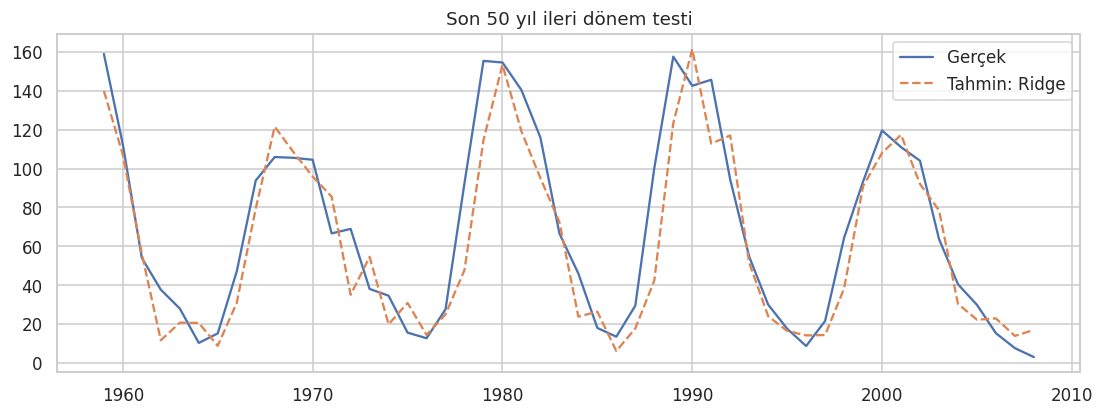

In [5]:
best_name = scores.index[0]; best_model = fitted[best_name]; best_pred = preds[best_name]
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test, label="Gerçek")
plt.plot(y_test.index, best_pred, "--", label=f"Tahmin: {best_name}")
plt.title("Son 50 yıl ileri dönem testi"); plt.legend(); plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "features": features.columns.tolist(),
             "metrics": scores.to_dict()}, MODEL_DIR / "16_gunes_lekesi.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "16_gunes_lekesi.json", "w"), indent=2)

## Sonuç

Otokorelasyon grafiği gecikmeli yapıyı veri üzerinden görünür kıldı. Yaklaşık 11 yıllık fiziksel
döngüyü temsil eden 11 ve 22 yıllık gecikmeler kullanıldı. Son 50 yıl test olarak ayrıldığı için
değerlendirme gerçek bir ileri tahmin senaryosuna yakındır.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **gecikme özellikleriyle tahmin** biçimindedir.
Bu notebookta **1700–2008 gerçek seri, otokorelasyon analizi, fiziksel döngü ve 50 yıllık ileri test** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).